In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

In [48]:
df = pd.read_csv("./clean_data.csv")
print(f"Number of Na:", "\n", df.isna().sum())
df = df.dropna()
df = df.drop(columns="index")

Number of Na: 
 index            0
rec_price_m      0
city             5
bathrooms        0
height           0
state            0
type             0
year             0
floor            0
max_floor        0
area           102
views          102
dist             0
cur_price_m    102
rating           0
dtype: int64


In [49]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 5304 entries, 0 to 5410
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   rec_price_m  5304 non-null   int64  
 1   city         5304 non-null   float64
 2   bathrooms    5304 non-null   int64  
 3   height       5304 non-null   float64
 4   state        5304 non-null   int64  
 5   type         5304 non-null   float64
 6   year         5304 non-null   int64  
 7   floor        5304 non-null   int64  
 8   max_floor    5304 non-null   int64  
 9   area         5304 non-null   float64
 10  views        5304 non-null   float64
 11  dist         5304 non-null   float64
 12  cur_price_m  5304 non-null   float64
 13  rating       5304 non-null   int64  
dtypes: float64(7), int64(7)
memory usage: 621.6 KB
None


In [50]:
display(df.describe())

,rec_price_m,city,bathrooms,height,state,type,year,floor,max_floor,area,views,dist,cur_price_m,rating
count,5304.000000,5304.000000,5304.000000,5304.000000,5304.000000,5304.000000,5304.000000,5304.000000,5304.000000,5304.000000,5304.000000,5304.000000,5.304000e+03,5304.0
mean,684295.535445,2.018477,1.161199,2.429253,3.015083,1.985671,2014.727187,5.979261,10.129525,43.196267,383.223982,5.753302,5.286718e+06,0.0
std,141618.517755,2.115119,0.367749,0.398309,1.027878,0.748738,15.590751,3.948225,4.621401,36.601391,1281.568925,23.086199,1.013966e+07,0.0
min,174130.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1945.000000,1.000000,1.000000,1.000000,0.000000,0.030766,6.024096e+03,0.0
25%,604170.000000,1.000000,1.000000,2.000000,3.000000,2.000000,2012.000000,3.000000,6.000000,6.000000,86.000000,2.984807,6.218688e+05,0.0
50%,670390.000000,2.000000,1.000000,2.700000,3.000000,2.000000,2022.000000,5.000000,9.000000,43.000000,173.000000,4.748149,8.666667e+05,0.0
75%,785092.500000,2.000000,1.000000,2.750000,4.000000,2.000000,2024.000000,9.000000,12.000000,67.000000,267.250000,6.808580,5.875000e+06,0.0
max,997820.000000,17.000000,2.000000,3.700000,5.000000,4.000000,2027.000000,28.000000,41.000000,300.000000,27384.000000,966.659309,1.360000e+08,0.0


<Axes: >

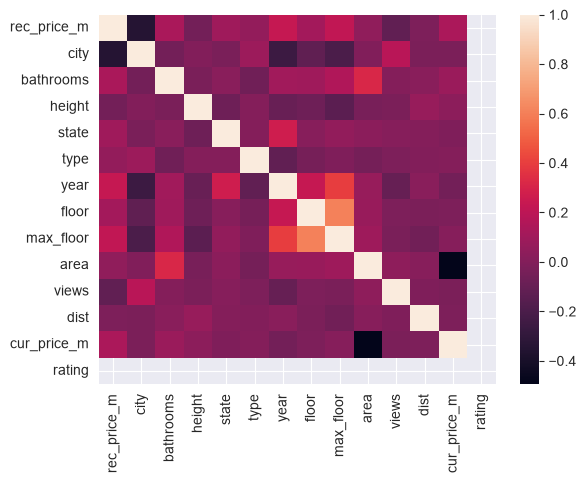

In [51]:
corr = df.corr()
sns.heatmap(corr)

<Axes: xlabel='state', ylabel='cur_price_m'>

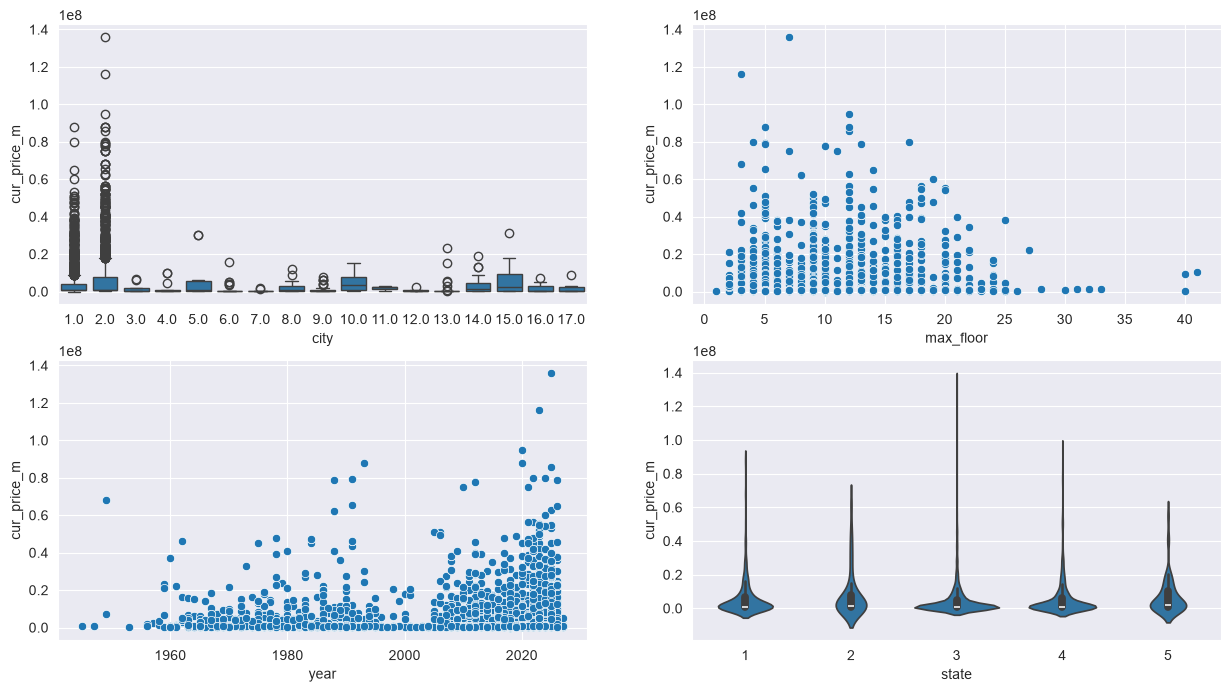

In [52]:
fig, ax = plt.subplots(2, 2, figsize=(15,8))
sns.boxplot(data=df, x="city", y="cur_price_m", ax=ax[0][0])
sns.scatterplot(data=df, x="max_floor", y="cur_price_m", ax=ax[0][1])
sns.scatterplot(data=df, x="year", y="cur_price_m", ax=ax[1][0])
sns.violinplot(data=df, x="state", y="cur_price_m")

<Axes: xlabel='state', ylabel='type'>

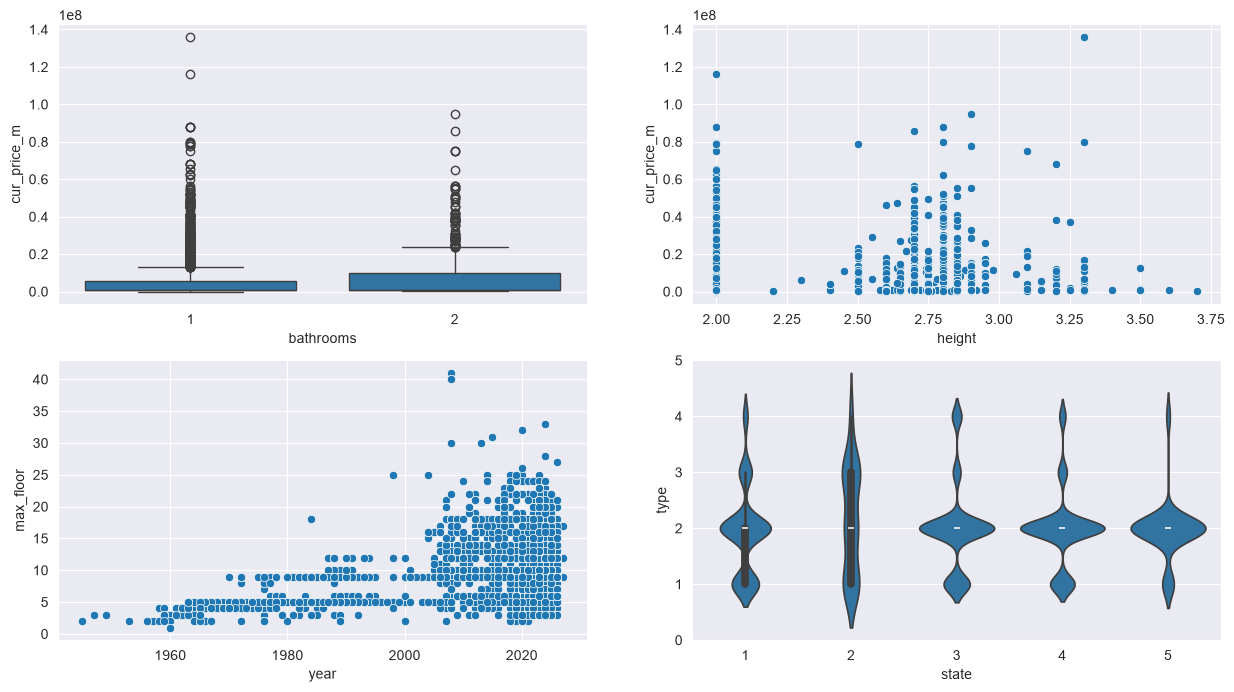

In [54]:
fig, ax = plt.subplots(2, 2, figsize=(15,8))
sns.boxplot(data=df, x="bathrooms", y="cur_price_m", ax=ax[0][0])
sns.scatterplot(data=df, x="height", y="cur_price_m", ax=ax[0][1])
sns.scatterplot(data=df, x="year", y="max_floor", ax=ax[1][0])
sns.violinplot(data=df, x="state", y="type")

In [ ]:
state_map = {
    'не новый, но аккуратный ремонт': 1,
    'требует ремонта': 2,
    'черновая отделка': 3,
    'свежий ремонт': 4,
    'свободная планировка': 5
}

city_map = {
    'астана': 1, 'алматы': 2, 'костанай': 3, 'усть-каменогорск': 4,
    'атырау': 5, 'актобе': 6, 'тараз': 7, 'шымкент': 8, 'караганда': 9,
    'семей': 10, 'талдыкорган': 11, 'кокшетау': 12, 'актау': 13,
    'павлодар': 14, 'уральск': 15, 'петропавловск': 16, 'темиртау': 17
}
types_map = {'кирпичный': 1, 'монолитный': 2, 'панельный': 3, 'иной': 4}